In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import classification_report

plt.rcParams['font.sans-serif'] = ['SimHei']  #黑体
plt.rcParams['axes.unicode_minus'] = False   #负号


In [2]:

def score(y_test, y_predict):
        accuracy=classification_report(y_test, y_predict,output_dict=True)['accuracy']
        s=classification_report(y_test, y_predict,output_dict=True)['1']
        precision=s['precision']
        recall=s['recall']
        f1_score=s['f1-score']
        return accuracy,precision,recall,f1_score

#导入数据
data = pd.read_excel('../data/data_train_smote.xlsx')
X_train = data.iloc[:,:-1]
Y_train = data.iloc[:,-1]
#X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=100)
data_test = pd.read_excel('../data/data_test.xlsx')
X_test = data_test.iloc[:,:-1]
Y_test = data_test.iloc[:,-1]



In [3]:

#导入10个模型
from sklearn.linear_model import LogisticRegression         #逻辑回归
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis        #线性判别分析
from sklearn.neighbors import KNeighborsClassifier          #K近邻
from sklearn.tree import DecisionTreeClassifier         #决策树
from sklearn.ensemble import RandomForestClassifier         #随机森林
from sklearn.ensemble import GradientBoostingClassifier         #梯度提升
from xgboost.sklearn import XGBClassifier       #极端梯度提升
from lightgbm import LGBMClassifier         #轻量梯度提升
from sklearn.svm import SVC         #支持向量机
from sklearn.neural_network import MLPClassifier        #神经网络

model1 =  LogisticRegression(#C=1e10,max_iter=10000
                                random_state=100
                                )
model2 = LinearDiscriminantAnalysis()
model3 = KNeighborsClassifier(#n_neighbors=10
                                )
model4 = DecisionTreeClassifier(random_state=100
                                )
model5= RandomForestClassifier(#n_estimators=1000,  max_features='sqrt',
                                random_state=100
                                )
model6 = GradientBoostingClassifier(random_state=100
                                        )
model7 =  XGBClassifier(#use_label_encoder=False,eval_metric=['logloss','auc','error'],
                        #objective='multi:softmax',
                        random_state=100
                        )
model8 = LGBMClassifier(#objective='multiclass',num_class=3,
                        random_state=100
                        )
model9 = SVC(#kernel="rbf", 
                random_state=100
                )
model10 = MLPClassifier(#hidden_layer_sizes=(16,8), random_state=77, max_iter=10000
                        random_state=100    
                        )
model_list=[model1,model2,model3,model4,model5,model6,model7,model8,model9,model10]
model_name=['逻辑回归','线性判别','K近邻','决策树','随机森林','梯度提升','极端梯度提升','轻量梯度提升','支持向量机','神经网络']


[LightGBM] [Info] Number of positive: 2189, number of negative: 12164
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000621 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3094
[LightGBM] [Info] Number of data points in the train set: 14353, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.152512 -> initscore=-1.715036
[LightGBM] [Info] Start training from score -1.715036


d:\develop\miniaconda\envs\python39\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


        Accuracy precision    recall  F1_score
逻辑回归    0.954063   0.54955  0.386076  0.453532
线性判别    0.944688  0.440252  0.443038   0.44164
K近邻      0.92625  0.278409  0.310127  0.293413
决策树      0.89875  0.225166   0.43038  0.295652
随机森林    0.963437  0.715789   0.43038  0.537549
梯度提升    0.954063  0.543307  0.436709  0.484211
极端梯度提升   0.94875  0.478571  0.424051  0.449664
轻量梯度提升  0.954375  0.544118  0.468354  0.503401
支持向量机   0.959063  0.736842  0.265823  0.390698
神经网络    0.948125  0.469697  0.392405  0.427586


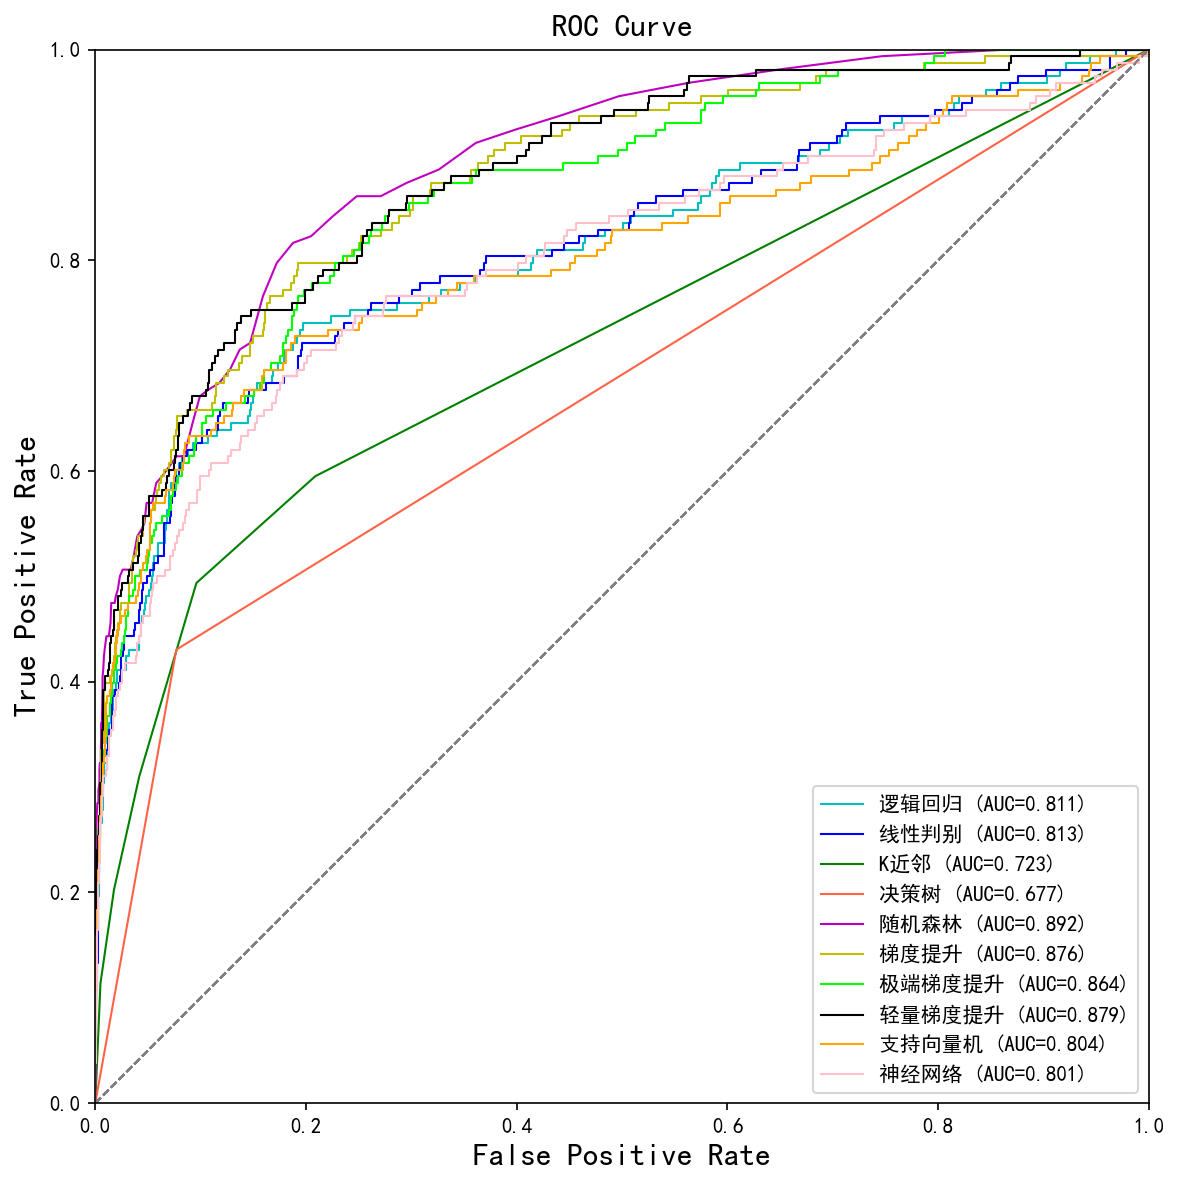

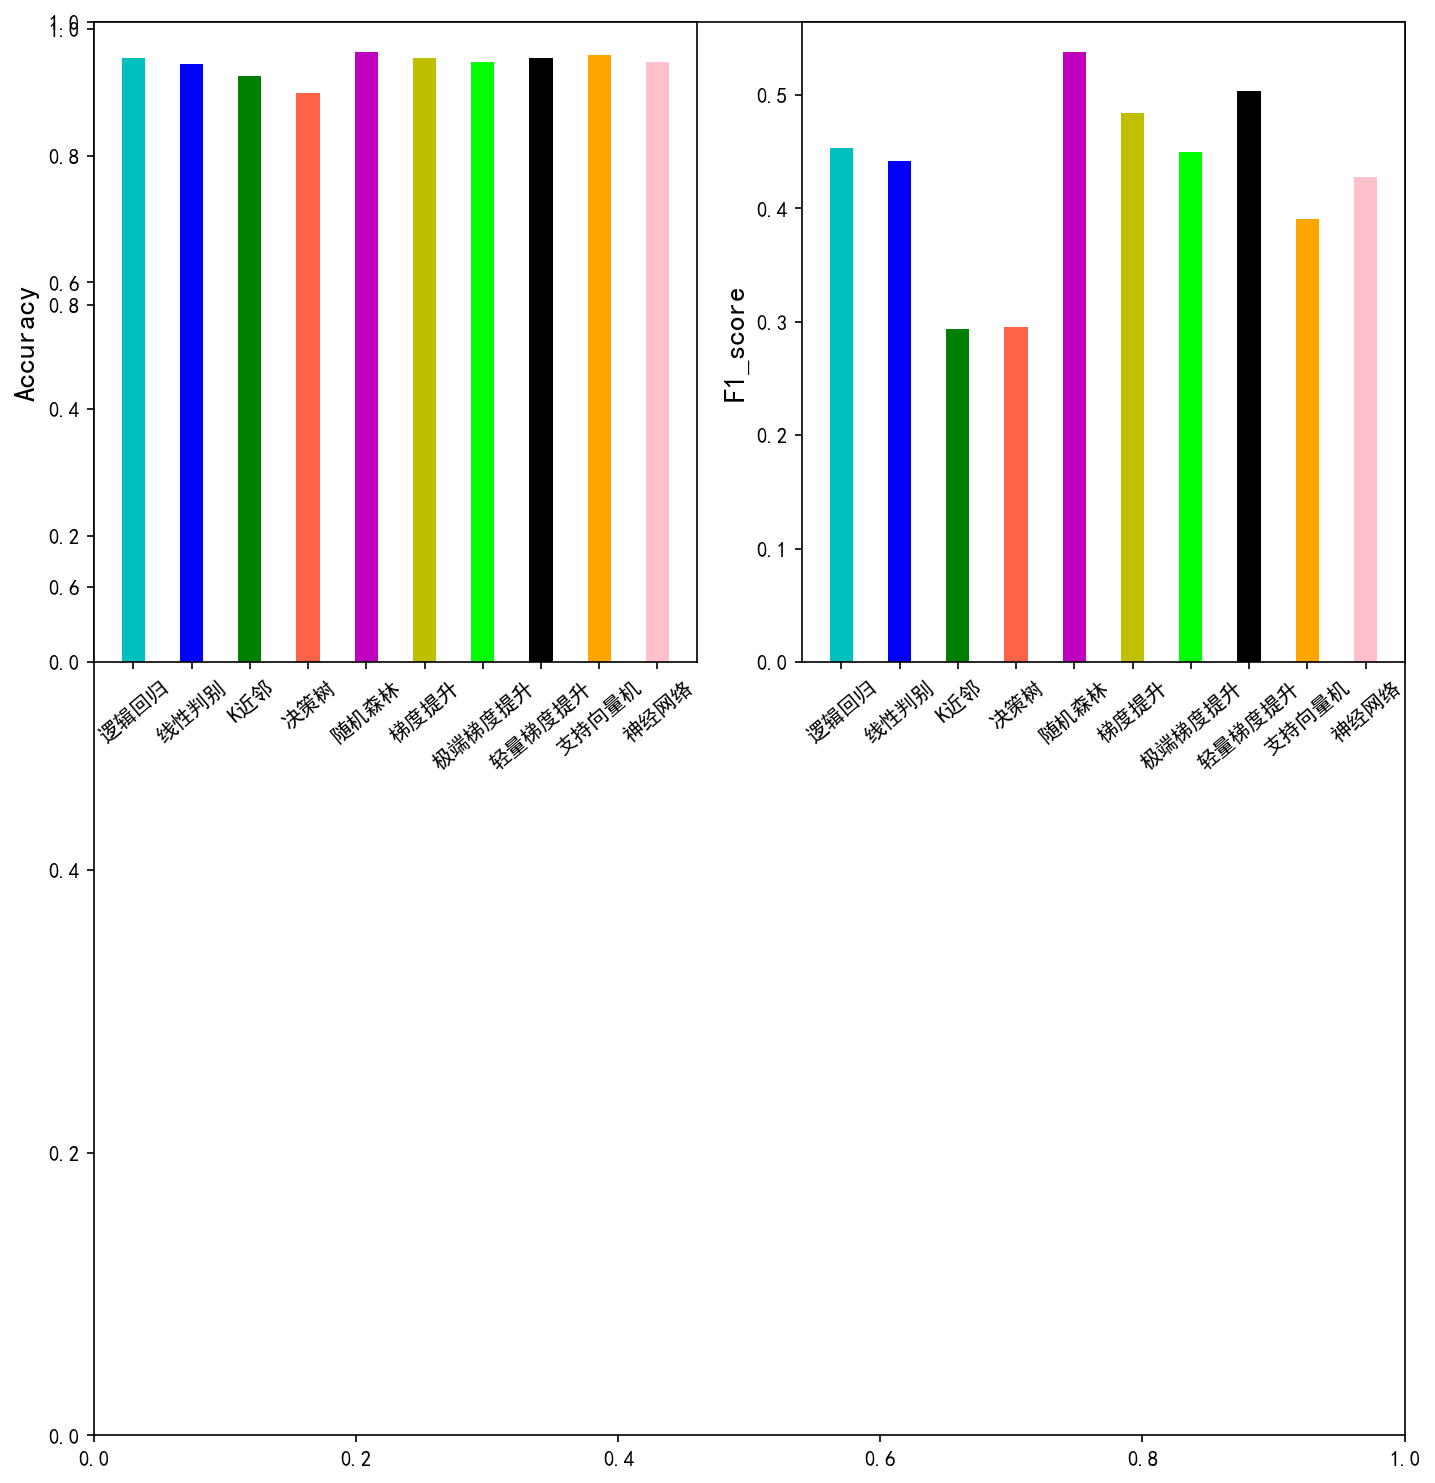

In [4]:

colors=['c', 'b', 'g', 'tomato', 'm', 'y', 'lime', 'k','orange','pink','grey','tan']
#colors = ['tab:blue','tab:orange','tab:green','tab:red','tab:purple','tab:brown','tab:pink','tab:gray','tab:olive','tab:cyan']
result = pd.DataFrame(columns=['Accuracy','precision','recall','F1_score'])

plt.figure(figsize=(12,8),dpi=150)
for i in range(10):
        model=model_list[i]
        name=model_name[i]
        model.fit(X_train, Y_train)
        Y_pred=model.predict(X_test)
        if name=='支持向量机':
                Y_score=model.decision_function(X_test)
                Y_pred_proba = 1 / (1 + np.exp(-Y_score))
        else:
                Y_pred_proba=model.predict_proba(X_test)[:, 1]
        fpr, tpr, thresholds = roc_curve(Y_test, Y_pred_proba,
                                        #pos_label=1
                                        )
        plt.plot(fpr, tpr, lw=1, label='{} (AUC={:.3f})'.format(name, auc(fpr, tpr)),color = colors[i])
        plt.plot([0, 1], [0, 1], '--', lw=1, color = 'grey')
        plt.axis('square')
        plt.xlim([0, 1])
        plt.ylim([0, 1])
        plt.xlabel('False Positive Rate',fontsize=15)
        plt.ylabel('True Positive Rate',fontsize=15)
        plt.title('ROC Curve',fontsize=15)
        plt.legend(loc='lower right',fontsize=10)
        plt.tight_layout()   
        #s=classification_report(Y_test, Y_pred)
        s=score(Y_test,Y_pred)
        result.loc[name,:]=list(s)

print(result)

#绘出各模型得分图
bar_width = 0.4
count = 0
plt.subplots(figsize=(10,10),dpi=150)
for index,column in enumerate(result.columns):
        if index == 0 or index == 3:
                n=int(str('22')+str(count+1))
                result_column = result[column]
                plt.subplot(n)
                plt.bar(range(len(result_column)),
                        height=result[column].to_numpy(),
                        width=bar_width,
                        color=colors
                        )
                plt.xticks(range(len(result_column)),
                        result_column.index,
                        fontsize=10,
                        rotation=40         #rotation:旋转x轴的标签
                        )        
                plt.ylabel(column,
                        fontsize=14
                        )
                count += 1
plt.tight_layout()             #自动调整子图参数,调整间隔，填充图像
plt.show()